<h2 align='center'> Zomato Restaurant Analysis </h2>


Zomato is looking for expansion and opening new restaurants. The objective is to come up with strategies/suggestions about opening newer restaurants.


## Table of Contents
1. [Importing Libraries](#import-libraries)
2. [Data Cleaning and Preprocessing](#data-cleaning)
3. [Feature Engineering](#feature-engineering)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
5. [Strategic Conclusion](#conclusion)

<a id="import-libraries"></a>
### <b>Importing Libraries</b>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
# Reading the data
df = pd.read_excel(r"D:\courses\Newton School\Excel\Zomato_Data_1.xlsx", sheet_name='Raw Data')
df.head()

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating,Datekey_Opening
0,18435314,Punjabi's Veg Grill,1,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,North Indian,Indian Rupees(Rs.),No,No,No,No,1,0,300,1.0,2013_9_21
1,18378015,Tasty Tandoor,1,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,North Indian,Indian Rupees(Rs.),No,No,No,No,1,0,200,1.0,2016_9_10
2,18424905,Taste of Spice,1,New Delhi,"C-222, Lajpat Nagar 1, New Delhi",Lajpat Nagar 1,"Lajpat Nagar 1, New Delhi",77.241312,28.578311,North Indian,Indian Rupees(Rs.),No,Yes,No,No,1,0,400,1.0,2018_9_25
3,18180072,Kolcata Bengali Dhaba,1,New Delhi,"Gali 7, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.123932,28.543587,North Indian,Indian Rupees(Rs.),No,No,No,No,1,0,100,1.0,2018_9_6
4,18415377,Sunil Punjabi Dhaba,1,New Delhi,"Main Vasant Kunj Road, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.129706,28.541369,North Indian,Indian Rupees(Rs.),No,No,No,No,1,0,150,1.0,2013_9_17


In [3]:
country_desc = pd.read_excel(r"D:\courses\Newton School\Excel\Zomato_Data_1.xlsx", sheet_name='country description')
country_desc

,Country Code,Country Name
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Philippines
7,166,Qatar
8,184,Singapore
9,189,South Africa


In [4]:
# Shape of the data
df.shape

(9551, 20)

In [5]:
# Checking data types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RestaurantID          9551 non-null   int64  
 1   RestaurantName        9551 non-null   object 
 2   CountryCode           9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   LocalityVerbose       9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Currency              9551 non-null   object 
 11  Has_Table_booking     9551 non-null   object 
 12  Has_Online_delivery   9551 non-null   object 
 13  Is_delivering_now     9551 non-null   object 
 14  Switch_to_order_menu  9551 non-null   object 
 15  Price_range          

In [6]:
# Checking the summary
df.describe()

,RestaurantID,CountryCode,Longitude,Latitude,Price_range,Votes,Average_Cost_for_two,Rating
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1.804837,156.909748,1199.210763,2.891268
std,8.791521e+06,56.750546,41.467058,11.007935,0.905609,430.169145,16121.183073,1.128845
min,5.300000e+01,1.000000,-157.948486,-41.330428,1.000000,0.000000,0.000000,1.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,1.000000,5.000000,250.000000,2.500000
50%,6.004089e+06,1.000000,77.191964,28.570469,2.000000,31.000000,400.000000,3.200000
75%,1.835229e+07,1.000000,77.282006,28.642758,2.000000,131.000000,700.000000,3.700000
max,1.850065e+07,216.000000,174.832089,55.976980,4.000000,10934.000000,800000.000000,4.900000


### **Data Cleaning and Preprocessing** <a id="data-cleaning"></a>

In [7]:
# Checking for null values
df.isna().sum()

RestaurantID            0
RestaurantName          0
CountryCode             0
City                    0
Address                 0
Locality                0
LocalityVerbose         0
Longitude               0
Latitude                0
Cuisines                9
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Is_delivering_now       0
Switch_to_order_menu    0
Price_range             0
Votes                   0
Average_Cost_for_two    0
Rating                  0
Datekey_Opening         0
dtype: int64

In [8]:
# Dropping the rows with null values
df = df.dropna()

# Checking for null values again
df.isna().sum()

RestaurantID            0
RestaurantName          0
CountryCode             0
City                    0
Address                 0
Locality                0
LocalityVerbose         0
Longitude               0
Latitude                0
Cuisines                0
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Is_delivering_now       0
Switch_to_order_menu    0
Price_range             0
Votes                   0
Average_Cost_for_two    0
Rating                  0
Datekey_Opening         0
dtype: int64

In [9]:
# Checking for duplicates in the data
df.duplicated().sum()

0

In [10]:
# Converting 'Datkey_Opening' to datetime
df['Datekey_Opening'] = df['Datekey_Opening'].replace("_","-", regex=True)
df['Datekey_Opening'] = pd.to_datetime(df['Datekey_Opening'])

### **Feature Engineering** <a id="feature-engineering"></a>

In [11]:
# Extracting year and month from the 'Datekey_Opening' column
df['Year'] = df['Datekey_Opening'].dt.year
df['Month'] = df['Datekey_Opening'].dt.month_name()

In [12]:
# Merging the 'country_desc' dataframe to df
df = df.merge(country_desc, left_on='CountryCode', right_on='Country Code', how='left')
df.head(2)

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating,Datekey_Opening,Year,Month,Country Code,Country Name
0,18435314,Punjabi's Veg Grill,1,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,North Indian,Indian Rupees(Rs.),No,No,No,No,1,0,300,1.0,2013-09-21,2013,September,1,India
1,18378015,Tasty Tandoor,1,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,North Indian,Indian Rupees(Rs.),No,No,No,No,1,0,200,1.0,2016-09-10,2016,September,1,India


In [13]:
# Coverting Has_Table_booking, Has_Online_delivery, Is_delivering_now, Switch_to_order_menu to Boolean for math operation

for column_name in ['Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu']:
    df[column_name] = df[column_name].map({'Yes':True, 'No':False})

df.head(2)

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating,Datekey_Opening,Year,Month,Country Code,Country Name
0,18435314,Punjabi's Veg Grill,1,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,North Indian,Indian Rupees(Rs.),False,False,False,False,1,0,300,1.0,2013-09-21,2013,September,1,India
1,18378015,Tasty Tandoor,1,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,North Indian,Indian Rupees(Rs.),False,False,False,False,1,0,200,1.0,2016-09-10,2016,September,1,India


<Axes: ylabel='Average_Cost_for_two'>

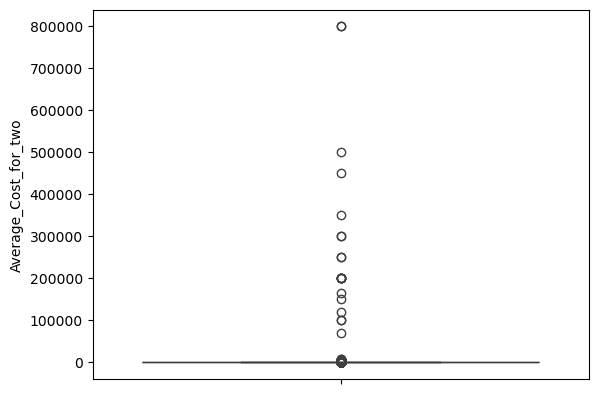

In [14]:
# Visualization to find outliers in 'Average_Cost_for_two' column
sns.boxplot(df['Average_Cost_for_two'])

In [15]:
# Calculating the Ouliers in the column 'Average_Cost_for_two'
Q1 = df['Average_Cost_for_two'].quantile(0.25)
Q2 = df['Average_Cost_for_two'].quantile(0.75)
IQR = Q2-Q1 
LL = Q1 - 1.5 * IQR
UL = Q2 + 1.5 * IQR
print(LL, UL)

# Creating Bins for the column 'Average_Cost_for_two'
bins = [0, 275, 550, 825, 1100, 1375, 800001]
labels = ['0-275', '275-550', '550-825', '825-1100', '1100-1375', '1375+']
df['Average_Cost'] = pd.cut(df['Average_Cost_for_two'], bins=bins, labels=labels, include_lowest=True)

-425.0 1375.0


<Axes: ylabel='Votes'>

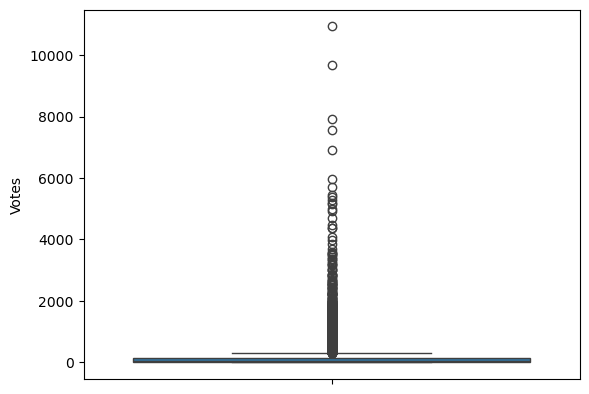

In [16]:
# Visualization to find outliers in 'Votes' column
sns.boxplot(df['Votes'])

In [17]:
# Calculating the Ouliers in the column 'Votes'
Q1 = df['Votes'].quantile(0.25)
Q2 = df['Votes'].quantile(0.75)
IQR = Q2-Q1 
LL = Q1 - 1.5 * IQR
UL = Q2 + 1.5 * IQR
print(LL, UL)

# Creating Bins for the column 'Votes'
bins = [0, 64, 128, 256, 512, 10934]
labels = ['0-64', '64-128', '128-256', '256-512', '512+']
df['Votes_Range'] = pd.cut(df['Votes'], bins=bins, labels=labels, include_lowest=True)

-182.5 317.5


<Axes: ylabel='Rating'>

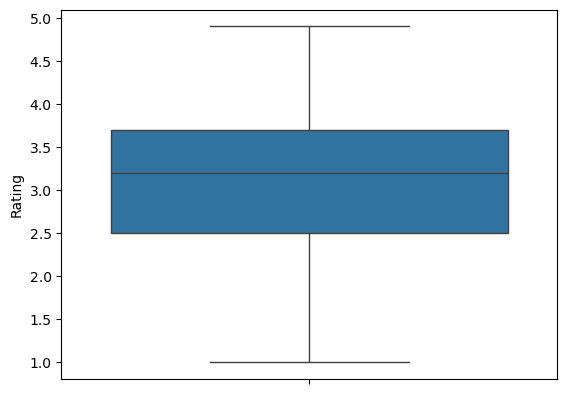

In [18]:
# Visualization to find outliers in 'Votes' column
sns.boxplot(df['Rating'])

In [19]:
# Creating Bins for the column 'Rating'
bins = [1, 2.6, 3.6, 4.6, 5.1]
labels = ['1-2.5', '2.6-3.5', '3.6-4.5', '4.6-5']
df['Rating_bins'] = pd.cut(df['Rating'], bins=bins, labels=labels, include_lowest=True)

In [20]:
# Droping columns 'RestaurantID' and 'RestaurantName' as they won't be required in the analysis
# Also dropping 'Country Code' column as there is duplicate column
# df = df.drop(columns=['RestaurantID', 'RestaurantName'])
df = df.drop(columns=['RestaurantName', 'Country Code'])

<a id="exploratory-data-analysis-eda"></a>
### **Exploratory Data Analysis (EDA)**

**Univariate Analysis**

In [21]:
# Total Restaurants 
print(f"Total Restaurants: {df['RestaurantID'].nunique()}")
print('-'*10, 'Number of Countries:', df['Country Name'].nunique(), sep='\n')
print('-'*10, 'Number of Cities:', df['City'].nunique(), sep='\n')

Total Restaurants: 9542
----------
Number of Countries:
15
----------
Number of Cities:
140


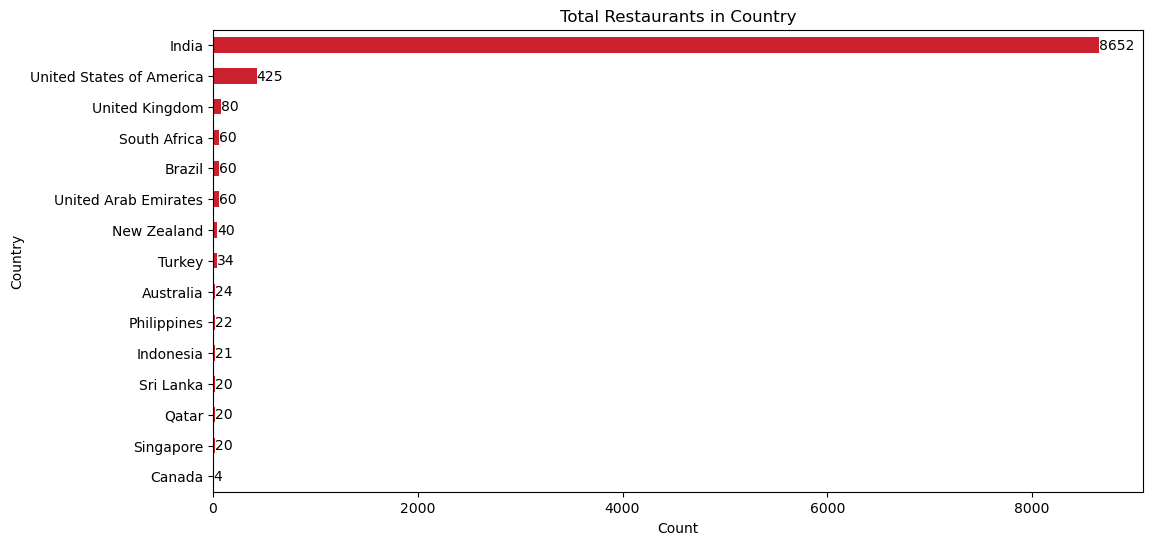

In [22]:
# Total Restaurants in Country
plt.figure(figsize=(12,6))
res_counts = df['Country Name'].value_counts().sort_values()
res_counts.plot(kind='barh', color='#CB202D')

for i, v in enumerate(res_counts):
    plt.text(v,i,str(v), va='center')

plt.title('Total Restaurants in Country')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

**Inida(8652)** has the highest number of restaurants followed by **United States of America(425), United Kingdom(80), South Africa(60), Brazil(60) and United Arab Emirates(60)**.  
**Canada(4)** has the lowest number of restaurants followed by **Sri Lanka(20), Qatar(20) and Singapore(20)**.  
Since **Canada** has very low number of restaurants, there can be **opportunity** for opening new restaurants.

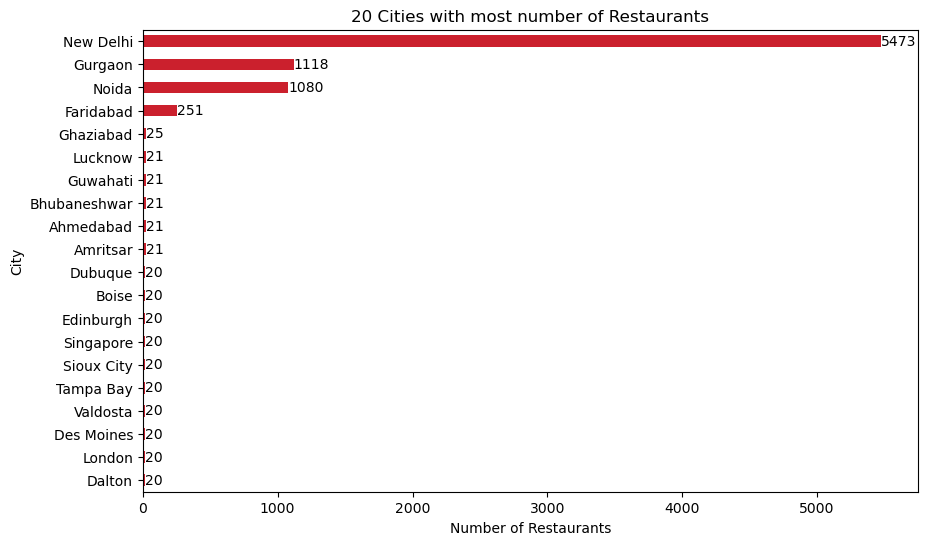

In [23]:
# City with most number of Restaurants
top_20_city = df['City'].value_counts().sort_values(ascending=False).head(20).sort_values()

top_20_city.plot(kind='barh', color='#CB202D', figsize=(10,6))

for i,v in enumerate(top_20_city):
    plt.text(v, i, str(v), ha='left', va='center')

plt.title('20 Cities with most number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.show()

**New Delhi(5473), Gurgaon(1118), Noida(1080), Faridabad(251)** has the highest number of restaurants.

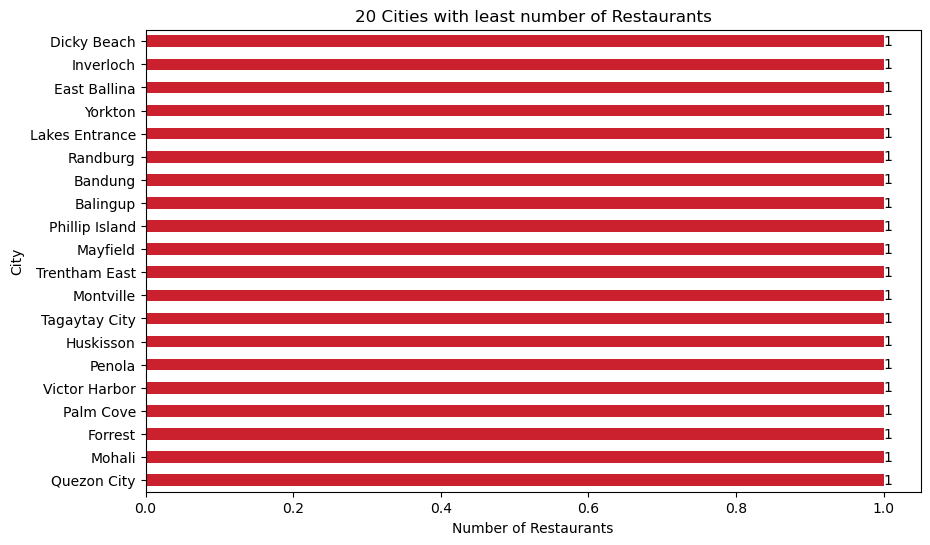

In [24]:
# City with least number of Restaurants
bottom_20_city = df['City'].value_counts().sort_values(ascending=True).head(20).sort_values()

bottom_20_city.plot(kind='barh', color='#CB202D', figsize=(10,6))

for i,v in enumerate(bottom_20_city):
    plt.text(v, i, str(v), ha='left', va='center')

plt.title('20 Cities with least number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.show()

In [25]:
# We see that there are many cities with just 1 restaurant.
# Getting all those cities

res_count = df['City'].value_counts().reset_index(name='res_count')
res_count_1 = res_count[res_count['res_count']==1]['City'].unique().tolist()
print(f"There are {len(res_count_1)} cities with only 1 restaurant: {res_count_1}")

There are 45 cities with only 1 restaurant: ['Dicky Beach', 'Inverloch', 'Mohali', 'Forrest', 'Palm Cove', 'Victor Harbor', 'Penola', 'Huskisson', 'Tagaytay City', 'Macedon', 'Montville', 'Trentham East', 'Mayfield', 'Phillip Island', 'Balingup', 'Bandung', 'Randburg', 'Lakes Entrance', 'Yorkton', 'East Ballina', 'Tanunda', 'Panchkula', 'Paynesville', 'Ojo Caliente', 'Vineland Station', 'Princeton', 'Vernonia', 'Lakeview', 'Fernley', 'Mc Millan', 'Clatskanie', 'Lincoln', 'Potrero', 'Weirton', 'Monroe', 'Cochrane', 'Winchester Bay', 'Chatham-Kent', 'Flaxton', 'Middleton Beach', 'Armidale', 'Beechworth', 'Consort', 'Lorn', 'Quezon City']


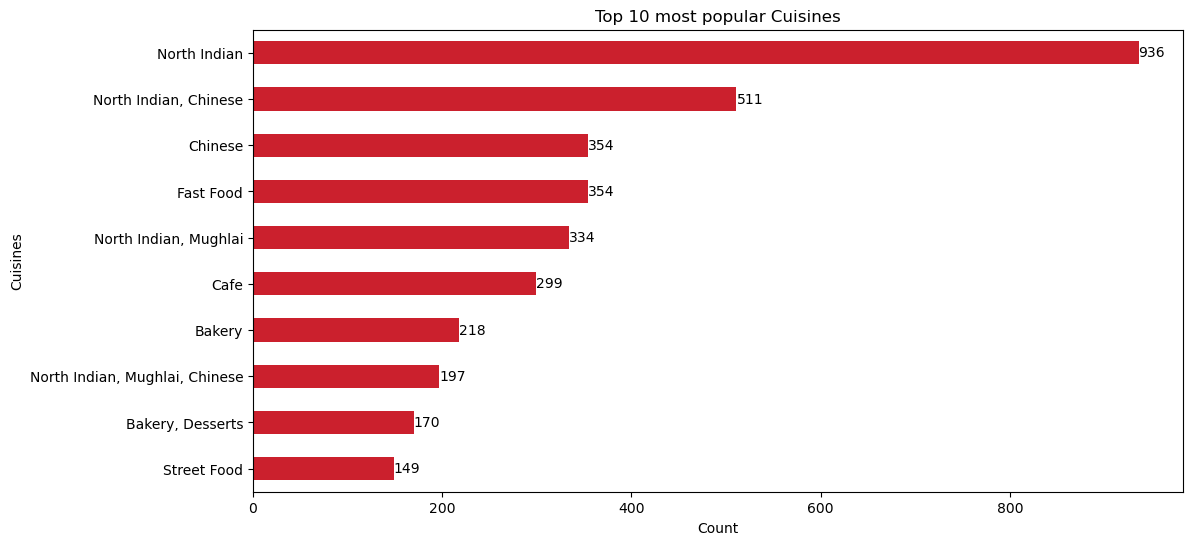

In [26]:
# Most Popular Cuisines
plt.figure(figsize=(12,6))
cus_counts = df['Cuisines'].value_counts(ascending=False).head(10).sort_values()
cus_counts.plot(kind='barh', color='#CB202D')

for i, v in enumerate(cus_counts):
    plt.text(v,i,str(v), va='center')

plt.title('Top 10 most popular Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisines')
plt.show()

**North Indian, Chinese, Fast Food, Mughlai** and **Cafe** are the top 5 Cusinies. 

In [27]:
# Count of Restaurants with Table Bookings
plt.figure(figsize=(6,6))

table_booking_count = df['Has_Table_booking'].value_counts(ascending=False).reset_index()
table_booking_count.columns = ['Has_Table_Booking', 'Count']

colors=['#CB202D', '#E0E0E0']
fig = px.pie(table_booking_count, names='Has_Table_Booking', values='Count', hole=0.6, color_discrete_sequence=colors)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Table Booking Distribution', title_x=0.5, showlegend=False)
fig.show()


<Figure size 600x600 with 0 Axes>

Only 12.1% of restaurants have Table Booking Option.

In [28]:
# Count of Restaurants with Online Delivery
plt.figure(figsize=(6,6))

online_delivery_count = df['Has_Online_delivery'].value_counts(ascending=False).reset_index()
online_delivery_count.columns = ['Has_Online_delivery', 'Count']

fig = px.pie(online_delivery_count, names='Has_Online_delivery', values='Count', hole=0.6, color_discrete_sequence=colors)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Online Delivery Distribution', title_x=0.5, showlegend=False)
fig.show()


<Figure size 600x600 with 0 Axes>

Only 25.7% restaurants have Online Delivery facility,

In [29]:
# Count of Restaurants with Is Delivering Now Option
plt.figure(figsize=(6,6))

is_delivering_count = df['Is_delivering_now'].value_counts(ascending=False).reset_index()
is_delivering_count.columns = ['Is_delivering_now', 'Count']

fig= px.pie(is_delivering_count, names='Is_delivering_now', values='Count', hole=0.6, color_discrete_sequence=colors)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Has Is Delivering Now Distribution', title_x=0.5, showlegend=False)
fig.show()

<Figure size 600x600 with 0 Axes>

Only 0.4% of the restaurants have Is Delivering Now Option.

In [30]:
# Count of Restaurants with Swtich to Order Menu Option
plt.figure(figsize=(6,6))

switch_to_order_menu_count = df['Switch_to_order_menu'].value_counts(ascending=False).reset_index()
switch_to_order_menu_count.columns = ['Switch_to_order_menu', 'Count']

fig = px.pie(switch_to_order_menu_count, names='Switch_to_order_menu', values='Count', hole=0.6, color_discrete_sequence=colors)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Has Switch to Order-Menu Distribution', title_x=0.5, showlegend=False)
fig.show()

<Figure size 600x600 with 0 Axes>

There are no restaurants with different ordering menu.

In [31]:
# Average Cost Distribution
plt.figure(figsize=(6,6))

avg_cost_count = df['Average_Cost'].value_counts(ascending=False).reset_index()
avg_cost_count.columns = ['Average_Cost', 'Count']

colors_six = ['#CB202D', '#E0E0E0', '#2E86AB', '#F6C85F', '#6F4E7C', '#9FD356']
fig = px.pie(avg_cost_count, names='Average_Cost', values='Count', hole=0.6, color_discrete_sequence=colors_six)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Average Cost Distribution', title_x=0.5, showlegend=False)
fig.show()

<Figure size 600x600 with 0 Axes>

0-550 is the price range in over 60% of the restaurants.

In [32]:
# Votes Distribution
plt.figure(figsize=(6,6))

avg_cost_count = df['Votes_Range'].value_counts(ascending=False).reset_index()
avg_cost_count.columns = ['Votes_range', 'Count']

fig = px.pie(avg_cost_count, names='Votes_range', values='Count', hole=0.6, color_discrete_sequence=colors_six)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Votes Distribution', title_x=0.5, showlegend=False)
fig.show()

<Figure size 600x600 with 0 Axes>

It can seen from the donut chart that only about 8% restaurants got votes greater than 512.

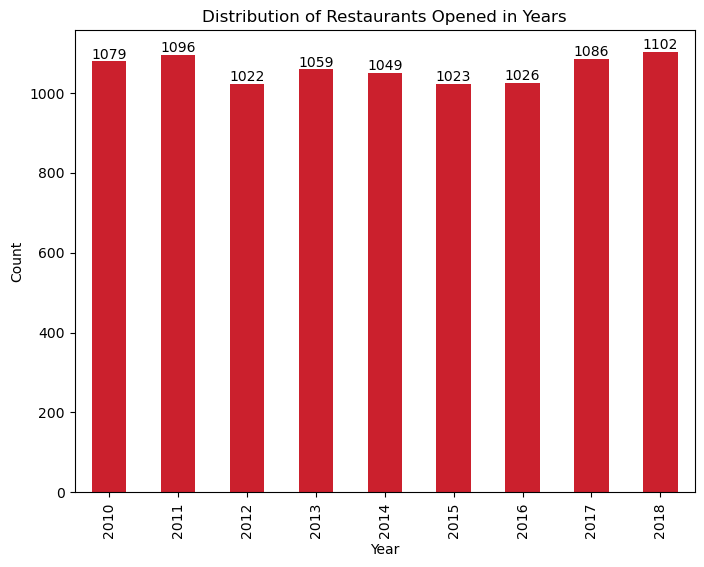

In [33]:
# Distribution of Restaurants Opened in Years
plt.figure(figsize=(8,6))

opening_year_count = df['Year'].value_counts().sort_index()

opening_year_count.plot(kind='bar', color='#CB202D')

for i, v in enumerate(opening_year_count):
    plt.text(i, v, str(v), va='bottom', ha='center')

plt.title('Distribution of Restaurants Opened in Years')
plt.ylabel('Count')
plt.xlabel('Year')
plt.show()

Between 2015 and 2018, there is a clear year-over-year increase, suggesting a slight but steady upward trend in market growth toward the end of the observed period.

In [34]:
# Distribution of Price Range
price_range_count = df['Price_range'].value_counts().reset_index()
price_range_count.columns = ['Price_range', 'Count']

fig = px.pie(price_range_count, names='Price_range', values='Count', color_discrete_sequence=['#CB202D', 'orange', 'yellow', 'blue'], hole=0.6)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Distribution of Price Range', title_x=0.5, showlegend=False)
fig.show()

46.5% restaurants have Price Range of 1  
32.6% restaurants have Price Range of 2   
14.7% restaurants have Price Range of 3  
6.14% restaurants have Price Range of 4 

In [35]:
# Distribution of Rating
rating_range_count = df['Rating_bins'].value_counts().reset_index()
rating_range_count.columns = ['Rating_bins', 'Count']

fig = px.pie(rating_range_count, names='Rating_bins', values='Count', color_discrete_sequence=['#CB202D', 'orange', 'yellow', 'blue'], hole=0.6)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Distribution of Rating', title_x=0.5, showlegend=False)
fig.show()

In [36]:
# Restaurant Density by Country
country_counts = df['Country Name'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

fig = px.choropleth(
    country_counts,
    locations='Country',
    locationmode='country names',
    color='Count',
    color_continuous_scale='Reds',
    title='Restaurant Density by Country'
)

fig.update_layout(title_x=0.5)
fig.show()

From the above choropleth chart, we see that **Canada** has a low restaurant count of 4 and its area is quite large. This gives a huge opportunity for new restaurants.

**Bivariate Analysis**

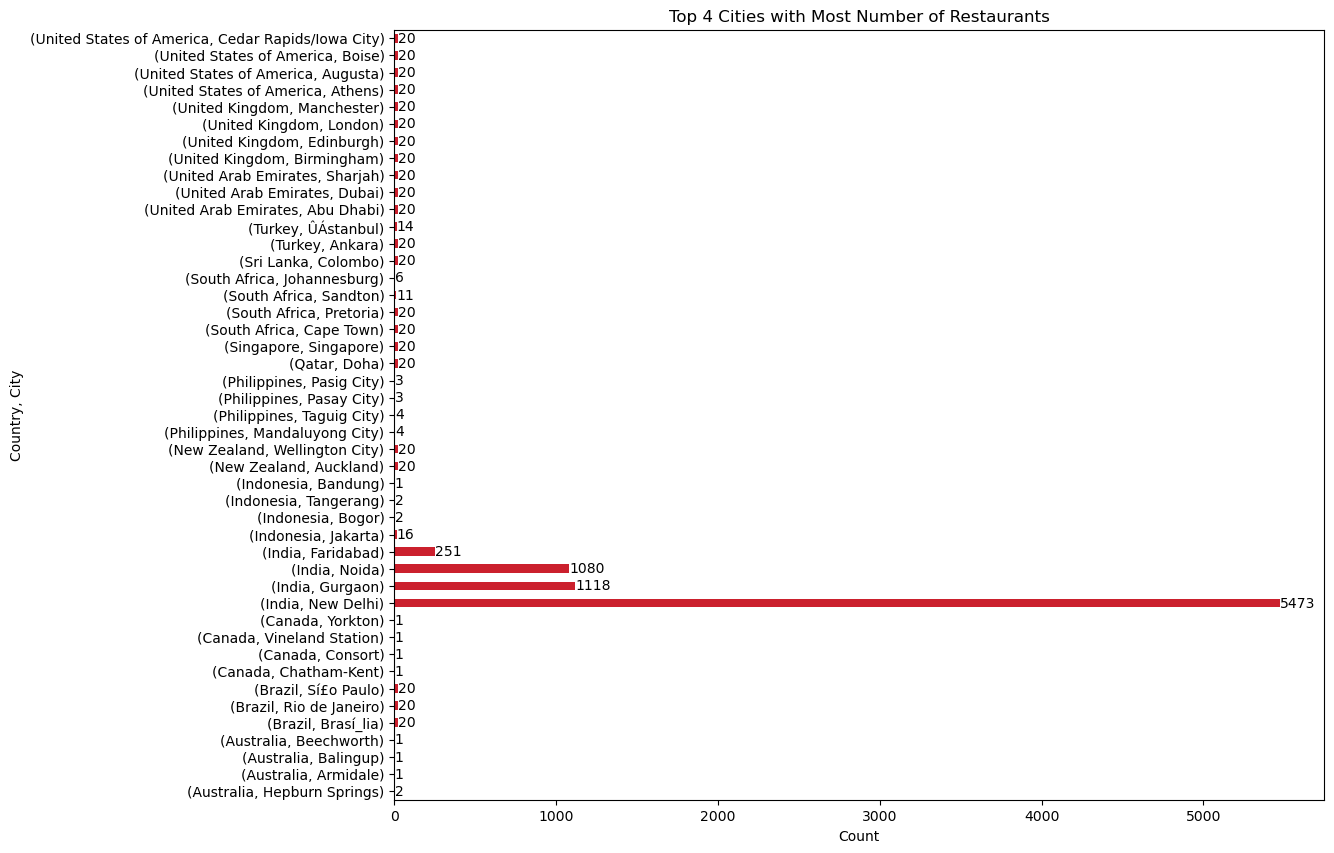

In [37]:
# Cities with highest number of Restaurants
top_3_per_country = (
    df.groupby(['Country Name', 'City'])['City'].count()
      .groupby(level=0, group_keys=False)
      .nlargest(4)
    #   .reset_index(name='Restaurant_Count')
)

plt.figure(figsize=(12,10))
top_3_per_country.plot(kind='barh', color='#CB202D')

for i, v in enumerate(top_3_per_country):
    plt.text(v, i, str(v), ha='left', va='center')

plt.title('Top 4 Cities with Most Number of Restaurants')
plt.xlabel('Count')
plt.ylabel('Country, City')
plt.show()

* **Canada - Yorkton, Vineland Station, Consort and Chatham-Kent**.  
* **Australia - Beechworth, Balingup and Armidale**.  
* **Indonesia - Bandung city**.  
These cities are best of opening restaurants as the count of restaurants is only 1 in the data. 

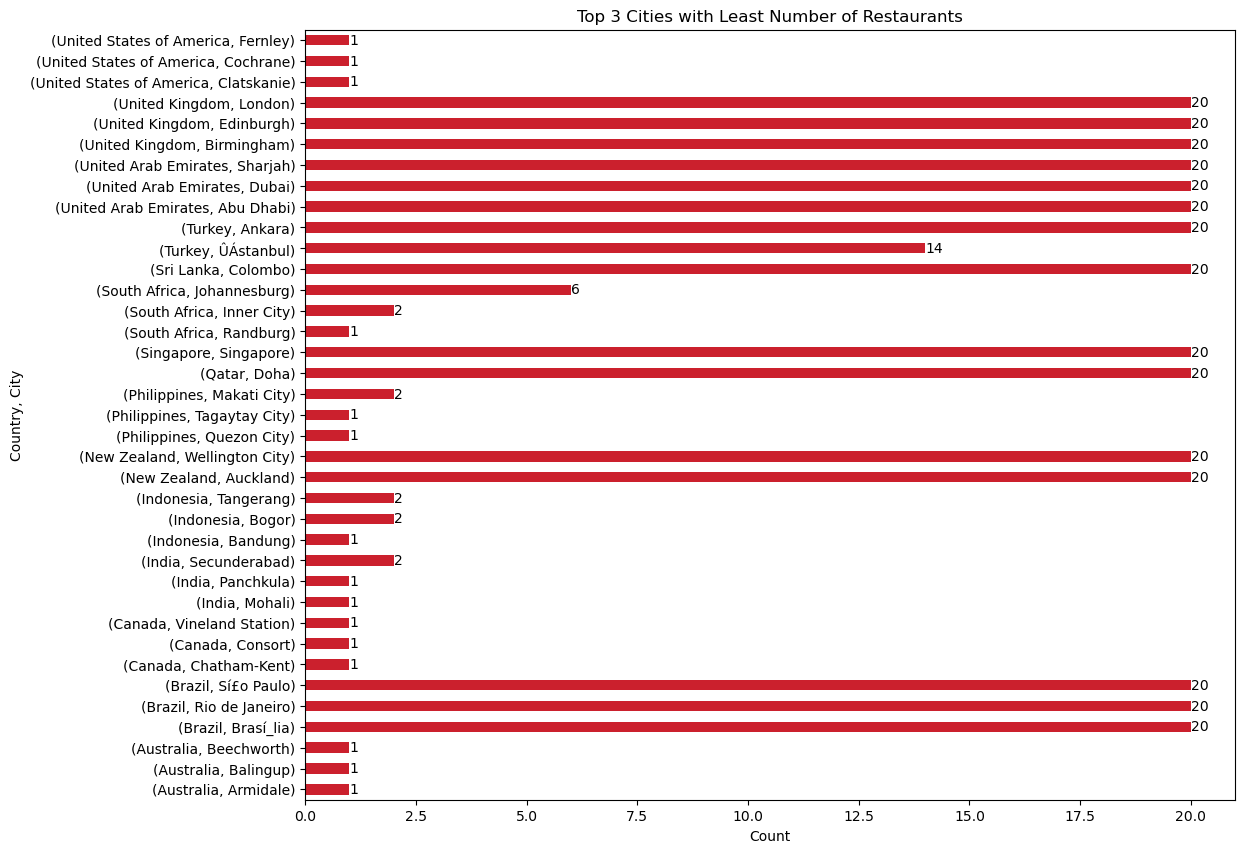

In [38]:
# Top 3 Cities with Least Number of Restaurants
bottom_3_per_country = (
    df.groupby(['Country Name', 'City'])['City'].count()
      .groupby(level=0, group_keys=False)
      .nsmallest(3)
    #   .reset_index(name='Restaurant_Count')
)

plt.figure(figsize=(12,10))
bottom_3_per_country.plot(kind='barh', color='#CB202D')

for i, v in enumerate(bottom_3_per_country):
    plt.text(v, i, str(v), ha='left', va='center')

plt.title('Top 3 Cities with Least Number of Restaurants')
plt.xlabel('Count')
plt.ylabel('Country, City')
plt.show()

We see that there are other cities with restaurant count as 1.  

In [39]:
# Checking for all the cities with Restaurant count as 1

res_count = df.groupby(['Country Name', 'City'])['City'].count().reset_index(name='Restaurant_Count')
res_count_1 = res_count[res_count['Restaurant_Count'] == 1]

country_with_res_count_1 = res_count_1['Country Name'].unique().tolist()
cities_with_res_count_1 = res_count_1['City'].unique().tolist()
print(len(cities_with_res_count_1))

print(f"List of Countries having Cities with Restaurant Count 1: {country_with_res_count_1}")

for country_name in res_count_1['Country Name'].unique():
    print(f"City Names in {country_name}:")
    print(res_count_1[res_count_1['Country Name'] == country_name]['City'].to_list()) 

45
List of Countries having Cities with Restaurant Count 1: ['Australia', 'Canada', 'India', 'Indonesia', 'Philippines', 'South Africa', 'United States of America']
City Names in Australia:
['Armidale', 'Balingup', 'Beechworth', 'Dicky Beach', 'East Ballina', 'Flaxton', 'Forrest', 'Huskisson', 'Inverloch', 'Lakes Entrance', 'Lorn', 'Macedon', 'Mayfield', 'Middleton Beach', 'Montville', 'Palm Cove', 'Paynesville', 'Penola', 'Phillip Island', 'Tanunda', 'Trentham East', 'Victor Harbor']
City Names in Canada:
['Chatham-Kent', 'Consort', 'Vineland Station', 'Yorkton']
City Names in India:
['Mohali', 'Panchkula']
City Names in Indonesia:
['Bandung']
City Names in Philippines:
['Quezon City', 'Tagaytay City']
City Names in South Africa:
['Randburg']
City Names in United States of America:
['Clatskanie', 'Cochrane', 'Fernley', 'Lakeview', 'Lincoln', 'Mc Millan', 'Monroe', 'Ojo Caliente', 'Potrero', 'Princeton', 'Vernonia', 'Weirton', 'Winchester Bay']


Above are the lists of all the Cities in different Countries where Restaurant Count is 1 and can be considered for opening new Restaurants.

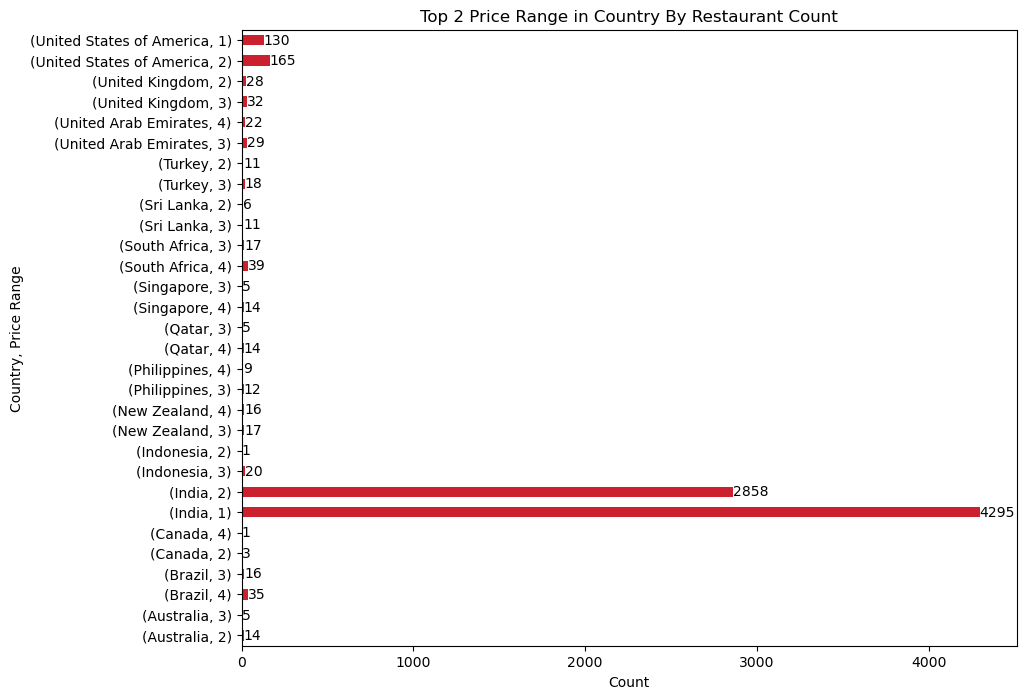

In [40]:
# Price Range of restaurants in different Countries
top_2_price_range = df.groupby(['Country Name', 'Price_range']).size().groupby(level=0, group_keys=False).nlargest(2)

top_2_price_range.plot(kind='barh', figsize=(10,8), color='#CB202D')

for i, v in enumerate(top_2_price_range):
    plt.text(v, i, str(v), ha='left', va='center')

plt.title('Top 2 Price Range in Country By Restaurant Count')
plt.xlabel('Count')
plt.ylabel('Country, Price Range')
plt.show()

In [41]:
top2 = top_2_price_range.reset_index()
top2.columns = ['Country', 'Price Range', 'Count']

fig = px.bar(top2,x='Count',y='Country',color='Price Range',orientation='h',
             title='Top 2 Price Ranges in Each Country by Restaurant Count',labels={'Count':'Number of Restaurants', 'Country':'Country'},height=700)

fig.update_layout(
    legend_title_text='Price Range',
    yaxis={'categoryorder':'total ascending'},
    title_x = 0.5
)

fig.show()

Price Range varies by Country, reflecting different economic conditions and dining cultures globally.  
In the populous countries like India and USA, Price Range is lower (1 or 2).  
Most countires Price Range is 3, indicating affordability drives demand.

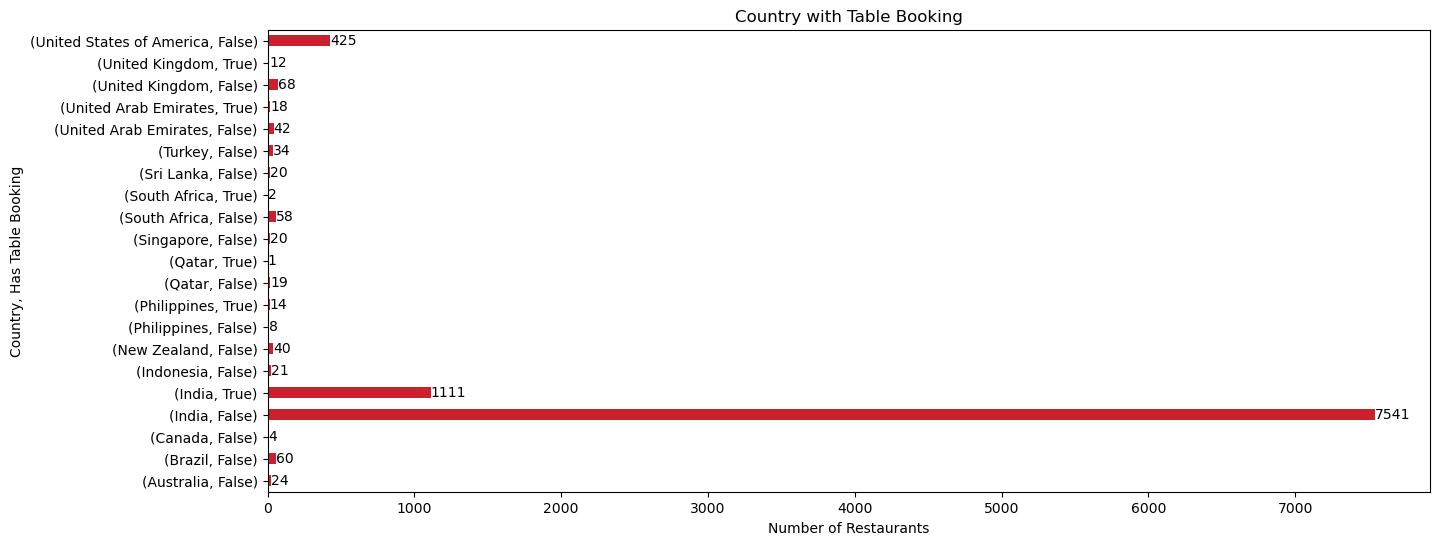

In [42]:
# Country with Table Booking
table_booking = df.groupby(['Country Name', 'Has_Table_booking']).size()

table_booking.plot(kind='barh', color='#CB202D', figsize=(15,6))

for i,v in enumerate(table_booking):
    plt.text(v,i,str(v), ha='left', va='center')

plt.title('Country with Table Booking')
plt.ylabel('Country, Has Table Booking')
plt.xlabel('Number of Restaurants')

plt.show()


# Ploty Interactive Chart
table_booking = df.groupby(['Country Name', 'Has_Table_booking']).size().reset_index(name='Count')

fig = px.bar(table_booking, x='Count', y='Country Name', color='Has_Table_booking', orientation='h',
             title='Country with Table Booking', labels={'Count':'Number of Restaurants'}, height=700)

fig.update_layout(
    legend_title_text='Table Booking',
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)

fig.show()

India has the highest number of restaurants overall. Most of these restaurants do not offer Table Booking but a significant portion does.  
USA has the second highest number of restaurants but none of them offer Table Booking.  
The presence of Table Booking varies significantly by country and among those countries very few restaurants offer Table Booking.

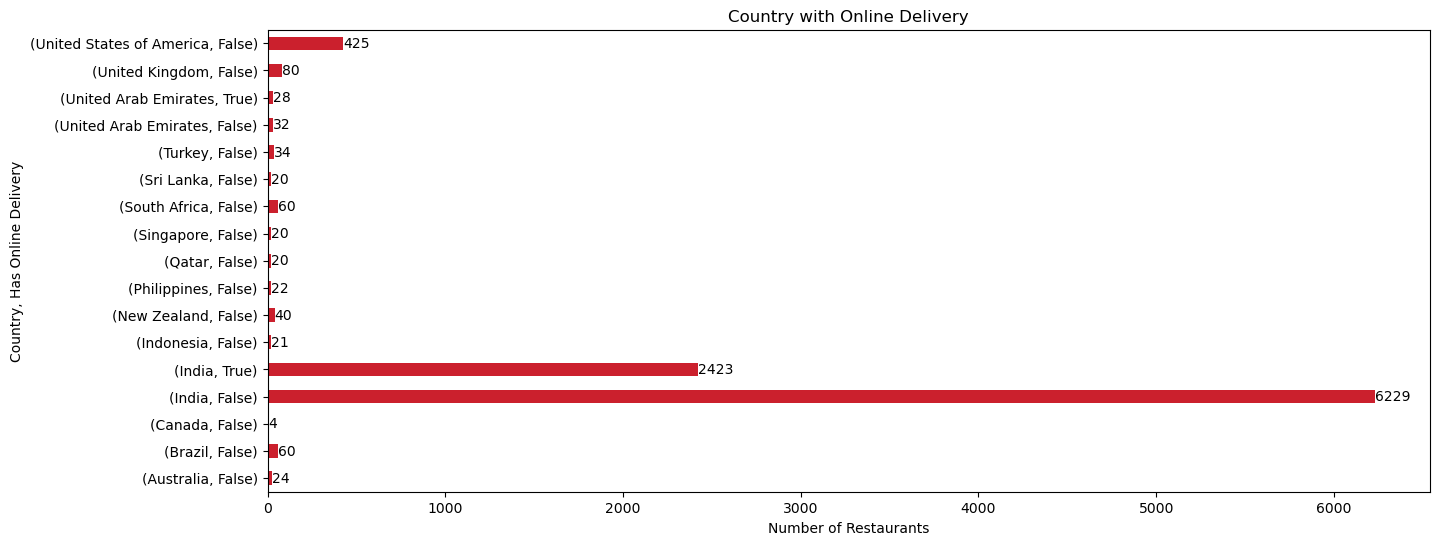

In [43]:
# Country with Online Delivery
table_booking = df.groupby(['Country Name', 'Has_Online_delivery']).size()

table_booking.plot(kind='barh', color='#CB202D', figsize=(15,6))

for i,v in enumerate(table_booking):
    plt.text(v,i,str(v), ha='left', va='center')

plt.title('Country with Online Delivery')
plt.ylabel('Country, Has Online Delivery')
plt.xlabel('Number of Restaurants')

plt.show()


# Ploty Interactive Chart
table_booking = df.groupby(['Country Name', 'Has_Online_delivery']).size().reset_index(name='Count')

fig = px.bar(table_booking, x='Count', y='Country Name', color='Has_Online_delivery', orientation='h',
             title='Country with Online Delivery', labels={'Count':'Number of Restaurants'}, height=700)

fig.update_layout(
    legend_title_text='Online Delivery',
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)

fig.show()

India and UAE are the only countires where Online Delivery is present.  
This shows that Online Delivery can be introduced in many countires.

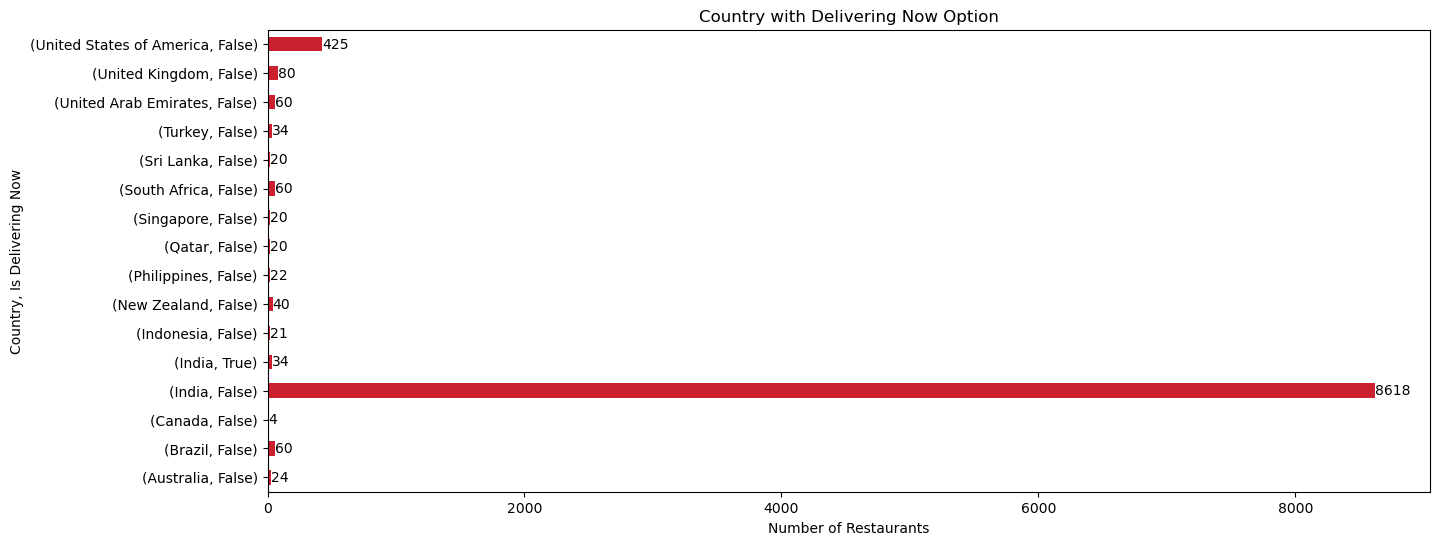

In [44]:
# Country with Delivering Now Option
table_booking = df.groupby(['Country Name', 'Is_delivering_now']).size()

table_booking.plot(kind='barh', color='#CB202D', figsize=(15,6))

for i,v in enumerate(table_booking):
    plt.text(v,i,str(v), ha='left', va='center')

plt.title('Country with Delivering Now Option')
plt.ylabel('Country, Is Delivering Now')
plt.xlabel('Number of Restaurants')

plt.show()


# Ploty Interactive Chart
table_booking = df.groupby(['Country Name', 'Is_delivering_now']).size().reset_index(name='Count')

fig = px.bar(table_booking, x='Count', y='Country Name', color='Is_delivering_now', orientation='h',
             title='Country with Delivering Now Option', labels={'Count':'Number of Restaurants'}, height=700)

fig.update_layout(
    legend_title_text='Delivering Now',
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)

fig.show()

Only India is providing Is Delivering Now option to the users.  
This feature can also be introduced in other Countries.

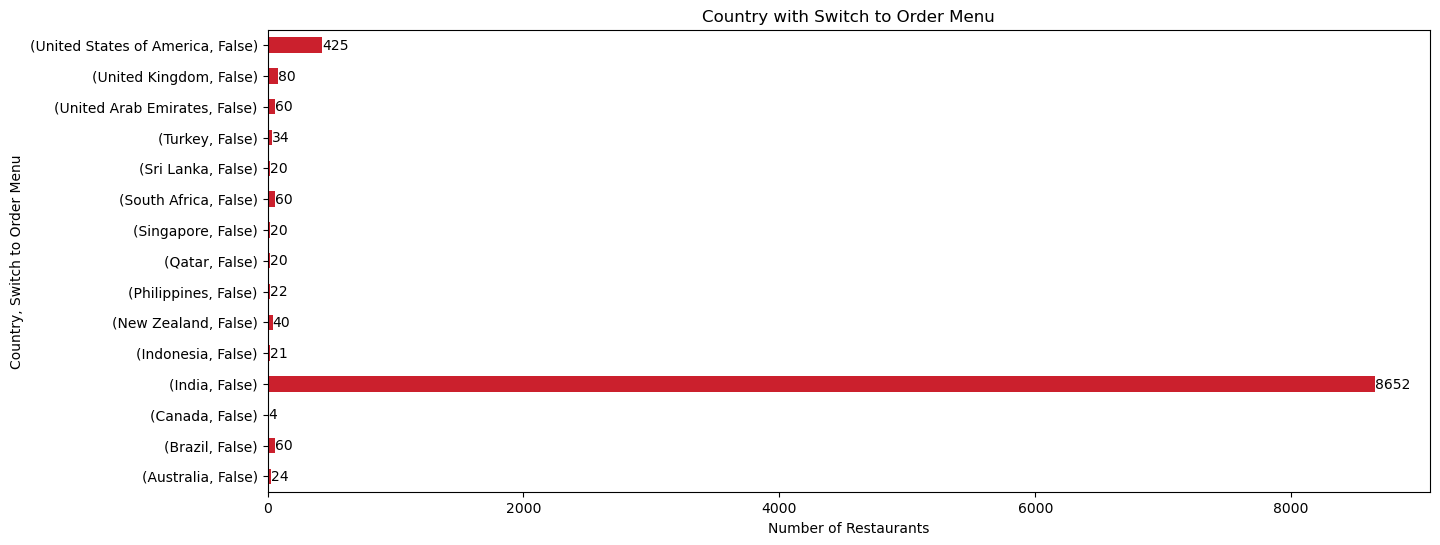

In [45]:
# Country with Switch to Order Menu
table_booking = df.groupby(['Country Name', 'Switch_to_order_menu']).size()

table_booking.plot(kind='barh', color='#CB202D', figsize=(15,6))

for i,v in enumerate(table_booking):
    plt.text(v,i,str(v), ha='left', va='center')

plt.title('Country with Switch to Order Menu')
plt.ylabel('Country, Switch to Order Menu')
plt.xlabel('Number of Restaurants')

plt.show()


# Ploty Interactive Chart
table_booking = table_booking.reset_index(name='Count')

fig = px.bar(table_booking, x='Count', y='Country Name', color='Switch_to_order_menu', orientation='h',
             title='Country with Switch to Order Menu', labels={'Count':'Number of Restaurants'}, height=700)

fig.update_layout(
    legend_title_text='Switch to Order Menu',
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)

fig.show()

No Country shows Switch to Order Menu Option.  
This feature is brand new and may catch attention.

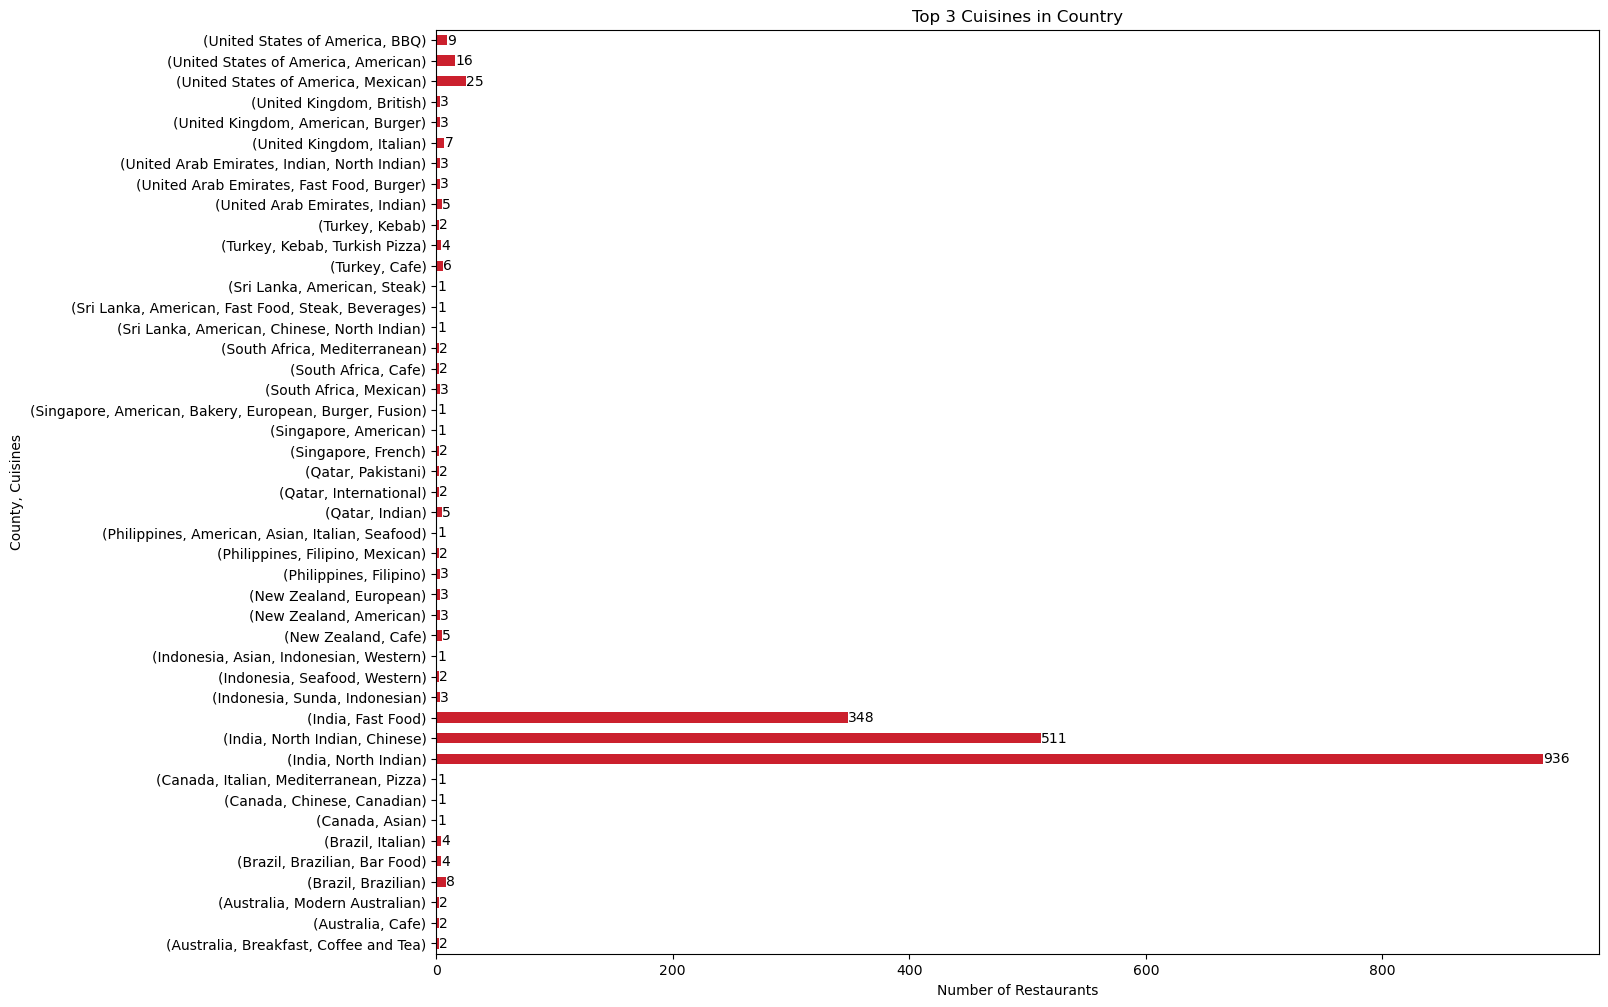

In [46]:
# Cusisine in Country
cuisine = df.groupby(['Country Name', 'Cuisines']).size().groupby(level=0, group_keys=False).nlargest(3)

cuisine.plot(kind='barh', color='#CB202D', figsize=(15,12))

for i, v in enumerate(cuisine):
    plt.text(v, i, str(v), ha='left', va='center')

plt.title('Top 3 Cuisines in Country')
plt.xlabel('Number of Restaurants')
plt.ylabel('County, Cuisines')
plt.show()

The above chart shows the top 3 cuisines in each Country.

Above is the top 3 Cusinies in the selected Countries.  
These Cuisines can be incorporated in the new restaurants in the selected Cities in addtion to the local Cuisines.

In [47]:
# Average Voters for restaurants in each Country
count = df.groupby('Country Name')['Votes'].mean().astype("int").sort_values().reset_index(name="Average Votes")

fig = px.bar(count, x="Average Votes", y="Country Name", text="Average Votes", title='Average Voters for Restaurants in each Country', 
             color_discrete_sequence=["#CB202D"])
fig.update_traces(textposition='outside', texttemplate='%{text:.0f}')
fig.update_layout(title_x=0.5)
fig.show()

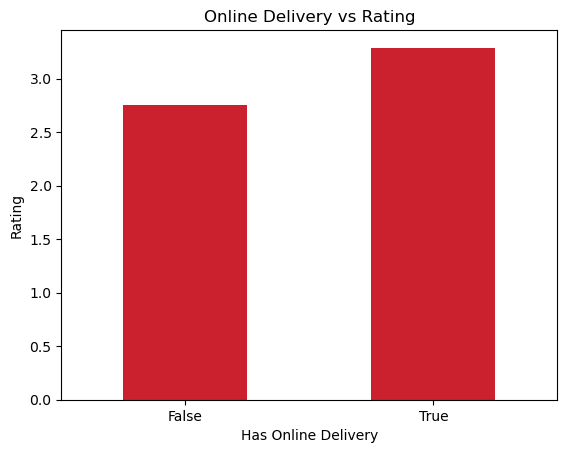

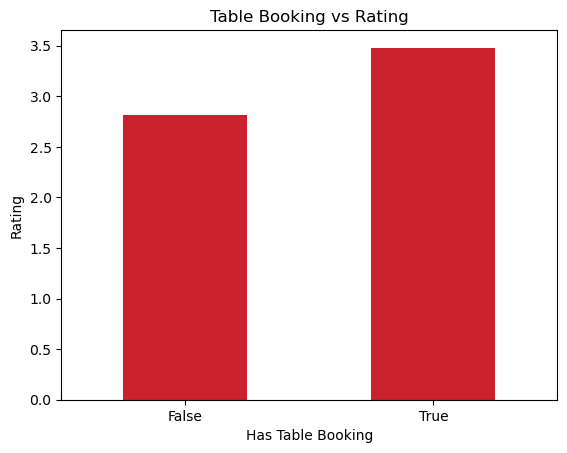

In [48]:
# Online Delivery vs Rating
df.groupby('Has_Online_delivery')['Rating'].mean().round(2).plot(kind='bar', color="#CB202D")
plt.title('Online Delivery vs Rating')
plt.ylabel('Rating')
plt.xticks(rotation=0)
plt.xlabel('Has Online Delivery')
plt.show()


# Table Booking vs Rating
df.groupby('Has_Table_booking')['Rating'].mean().round(2).plot(kind='bar', color="#CB202D")
plt.title('Table Booking vs Rating')
plt.ylabel('Rating')
plt.xticks(rotation=0)
plt.xlabel('Has Table Booking')
plt.show()

In [49]:
# Top 10 Cuisines Globally with highest average rating
df['Cuisines'] = df['Cuisines'].str.split(',')

df_exploded = df.explode('Cuisines')

df_exploded['Cuisines'] = df_exploded['Cuisines'].str.strip()

df_exploded.groupby('Cuisines')['Rating'].mean().sort_values(ascending=False).head(10).round(2).reset_index()

,Cuisines,Rating
0,Sunda,4.90
1,Bí_rek,4.70
2,Taiwanese,4.65
3,Ramen,4.50
4,Dim Sum,4.47
5,Hawaiian,4.41
6,Dí_ner,4.40
7,Bubble Tea,4.40
8,Curry,4.40
9,Kebab,4.38


10 Cuisines with highest average rating are Sunda, Bi_rek, Taiwanese, Ramen, Dim Sum, Hawaiian, Di_ner, Curry, Kebab.

In [50]:
# Top 10 Cuisines with most number of occurances globally
df_exploded['Cuisines'].value_counts().head(10).reset_index()

,Cuisines,count
0,North Indian,3960
1,Chinese,2735
2,Fast Food,1986
3,Mughlai,995
4,Italian,764
5,Bakery,745
6,Continental,736
7,Cafe,703
8,Desserts,653
9,South Indian,636


Top 10 most occuring Cuisines are North Indian, Chinese, Fast Food, Mughlai, Italian, Bakery, Continental, Cafe, Desserts and South Indian.

In [51]:
# Top 10 Cuisines in India with highest average rating
df_exploded[df_exploded['Country Name'] == 'India'].groupby('Cuisines')['Rating'].mean().sort_values(ascending=False).head(10).round(2).reset_index()

,Cuisines,Rating
0,Persian,4.60
1,German,4.35
2,Modern Indian,4.28
3,Charcoal Grill,4.18
4,Parsi,4.10
5,Iranian,4.07
6,Burmese,4.05
7,Steak,4.05
8,Spanish,4.03
9,Sri Lankan,4.00


Top 10 most occuring Cuisines in India are Persian, German, Mordern Indian, Charcoal Grill, Parsi, Iranian, Burmese, Steak, Spanish and Sri Lankan.

In [52]:
# Top 10 Cuisines with most number of occurances in India
df_exploded[df_exploded['Country Name'] == 'India']['Cuisines'].value_counts().head(10).reset_index()

,Cuisines,count
0,North Indian,3946
1,Chinese,2690
2,Fast Food,1963
3,Mughlai,992
4,Bakery,726
5,Continental,724
6,Italian,682
7,South Indian,631
8,Cafe,627
9,Desserts,597


We get the same result for India as the result was for Global data.

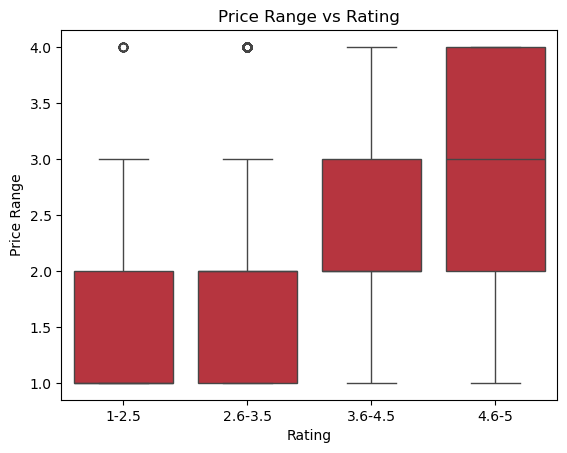

In [53]:
# Price Range vs Rating
sns.boxplot(data=df, x='Rating_bins', y='Price_range', color="#CB202D")
plt.title("Price Range vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price Range")
plt.show()

* `sns.boxplot` reveals that mid-range price categories (Price Range 2 and 3) offer the most consistent distribution of high ratings, particularly in the 3.6–4.5 rating bins.  
* A higher price range does not linearly correlate with an elite rating. The data shows that restaurants in Price Range 2 frequently achieve the same "Excellent" (4.6–5.0) status as those in Price Range 4, suggesting that customer satisfaction is driven by value rather than cost alone[cite: 1].

**Figuring out Cities for new Restaurants**

In [54]:
city_analysis = df.groupby(['Country Name', 'City']).agg(Total_Restaurants = ('RestaurantID', 'count'),
                                                         Avg_rating = ('Rating', 'mean'),
                                                         Delivery_Penetration = ('Has_Online_delivery', 'mean'),
                                                         Avg_Price_Range = ('Price_range', 'mean')).reset_index()

median_density = city_analysis['Total_Restaurants'].median()

city_analysis['Opportunity_score'] = city_analysis['Total_Restaurants']/city_analysis['Avg_rating']
# High scores highlight cities with high demand (density) but poor performance (low ratings).

city_analysis = city_analysis[city_analysis['Total_Restaurants']>median_density]
# We only analyze cities above the Median Density to ensure the market is large enough to sustain a new business.

city_analysis.sort_values(by="Opportunity_score", ascending=False)
# Focuses entry on "underserved" hubs where a high-quality restaurant can easily capture market share from low-rated competitors.

,Country Name,City,Total_Restaurants,Avg_rating,Delivery_Penetration,Avg_Price_Range,Opportunity_score
61,India,New Delhi,5473,2.699214,0.272063,1.621597,2027.627058
62,India,Noida,1080,2.391759,0.337037,1.601852,451.550463
45,India,Gurgaon,1118,2.855367,0.380143,1.855993,391.543401
42,India,Faridabad,251,2.265339,0.139442,1.454183,110.800211
43,India,Ghaziabad,25,2.932000,0.400000,1.800000,8.526603
33,India,Amritsar,21,3.685714,0.000000,1.809524,5.697674
37,India,Bhubaneshwar,21,3.980952,0.000000,1.857143,5.275120
31,India,Ahmedabad,21,4.161905,0.523810,2.571429,5.045767
46,India,Guwahati,21,4.190476,0.000000,2.523810,5.011364
53,India,Lucknow,21,4.195238,0.000000,2.571429,5.005675


Let's Interpret the results:
* **High Opportunity Score-** Indicates opportunity for new business as there is a supply-quality mismtach. Meaning despite the high number of choices, the average reating is low. Customers are spending money but are not satisfied with their current options. A new entry that provides high quality food and service can easily disrupt the market and steal customers from eastablished but mediocre customers.
* **Low opportunity Score-** Indicates a Balanced or Saturated Market. The existing restaurants are performing well and have high ratings, meaning customers are loyal and happy. Breaking into this market would be difficult and expensive.

In [55]:
# SEGMENTATION OF INSIGHTS

# A. Quality Disruptors (India Focus)
quality_gap_india = city_analysis[city_analysis['Country Name'] == 'India'].sort_values(by='Opportunity_score', ascending=False)
quality_gap_india

,Country Name,City,Total_Restaurants,Avg_rating,Delivery_Penetration,Avg_Price_Range,Opportunity_score
61,India,New Delhi,5473,2.699214,0.272063,1.621597,2027.627058
62,India,Noida,1080,2.391759,0.337037,1.601852,451.550463
45,India,Gurgaon,1118,2.855367,0.380143,1.855993,391.543401
42,India,Faridabad,251,2.265339,0.139442,1.454183,110.800211
43,India,Ghaziabad,25,2.932000,0.400000,1.800000,8.526603
33,India,Amritsar,21,3.685714,0.000000,1.809524,5.697674
37,India,Bhubaneshwar,21,3.980952,0.000000,1.857143,5.275120
31,India,Ahmedabad,21,4.161905,0.523810,2.571429,5.045767
46,India,Guwahati,21,4.190476,0.000000,2.523810,5.011364
53,India,Lucknow,21,4.195238,0.000000,2.571429,5.005675


In [56]:
# B. Delivery Growth Markets (Low Penetration)
delivery_gap = city_analysis[city_analysis['Delivery_Penetration'] < 0.2].sort_values(by='Total_Restaurants', ascending=False)
delivery_gap

,Country Name,City,Total_Restaurants,Avg_rating,Delivery_Penetration,Avg_Price_Range,Opportunity_score
42,India,Faridabad,251,2.265339,0.139442,1.454183,110.800211
33,India,Amritsar,21,3.685714,0.000000,1.809524,5.697674
37,India,Bhubaneshwar,21,3.980952,0.000000,1.857143,5.275120
46,India,Guwahati,21,4.190476,0.000000,2.523810,5.011364
53,India,Lucknow,21,4.195238,0.000000,2.571429,5.005675


In [57]:
# C. The "Pioneer" Strategy (International Cities with only 1 restaurant)
# We go back to the original DF for this
pioneer_cities = df.groupby(['Country Name', 'City']).size().reset_index(name='Count')
pioneer_list = pioneer_cities[pioneer_cities['Count'] == 1]
pioneer_list

,Country Name,City,Count
0,Australia,Armidale,1
1,Australia,Balingup,1
2,Australia,Beechworth,1
3,Australia,Dicky Beach,1
4,Australia,East Ballina,1
5,Australia,Flaxton,1
6,Australia,Forrest,1
8,Australia,Huskisson,1
9,Australia,Inverloch,1
10,Australia,Lakes Entrance,1


In [58]:
# D. The "Affordable Quality" Gap 
# Cities with high average price but low ratings (Customers are paying a lot for bad food)
price_gap = city_analysis.sort_values(by=['Avg_Price_Range', 'Avg_rating'], ascending=[False, True])
price_gap

,Country Name,City,Total_Restaurants,Avg_rating,Delivery_Penetration,Avg_Price_Range,Opportunity_score
31,India,Ahmedabad,21,4.161905,0.523810,2.571429,5.045767
53,India,Lucknow,21,4.195238,0.000000,2.571429,5.005675
46,India,Guwahati,21,4.190476,0.000000,2.523810,5.011364
37,India,Bhubaneshwar,21,3.980952,0.000000,1.857143,5.275120
45,India,Gurgaon,1118,2.855367,0.380143,1.855993,391.543401
33,India,Amritsar,21,3.685714,0.000000,1.809524,5.697674
43,India,Ghaziabad,25,2.932000,0.400000,1.800000,8.526603
61,India,New Delhi,5473,2.699214,0.272063,1.621597,2027.627058
62,India,Noida,1080,2.391759,0.337037,1.601852,451.550463
42,India,Faridabad,251,2.265339,0.139442,1.454183,110.800211


In [59]:
# Density vs Quality 
plot_df = city_analysis

fig = px.scatter(plot_df, x='Total_Restaurants', y='Avg_rating', size='Opportunity_score', color='Avg_Price_Range', 
                 hover_name='City', title='<b>Market Gap Analysis: Density vs Quality</b>',
                 labels={'Total_Restaurants': 'Number of Restaurants',  'Avg_Rating': 'Average Rating', 'Opportunity_score': 'Opportunity Score'},
                 color_continuous_scale='Viridis', template='plotly_white', height=600)

global_avg = df['Rating'].mean()
fig.add_hline(y=global_avg, line_dash="dash", line_color="red", annotation_text=f"Global Avg Rating: {global_avg:.2f}",annotation_position="bottom right")

fig.show()

In [60]:
from IPython.display import display, Markdown

avg_price = quality_gap_india['Avg_Price_Range'].iloc[0]
city_name = quality_gap_india['City'].iloc[0]
price_advice = "Premium/Fine-Dining" if avg_price > 2.5 else "Value/Budget"

conclusion_md = f"""
## --- STRATEGIC CONCLUSION ---

1. **QUALITY DISRUPTORS:** {', '.join(quality_gap_india['City'].head(3).tolist())} show massive density but low satisfaction.
2. **DELIVERY GAPS:** {', '.join(delivery_gap['City'].head(3).tolist())} have high restaurant counts but < 20% delivery penetration.
3. **PIONEER OPPORTUNITIES:** Found **{len(pioneer_list)}** cities globally (e.g., {pioneer_list['City'].iloc[0]}) with zero competition.
4. **PRICING STRATEGY:** In **{city_name}**, the average price range is **{avg_price:.1f}**, suggesting a **{price_advice}** model.
"""

display(Markdown(conclusion_md))


## --- STRATEGIC CONCLUSION ---

1. **QUALITY DISRUPTORS:** New Delhi, Noida, Gurgaon show massive density but low satisfaction.
2. **DELIVERY GAPS:** Faridabad, Amritsar, Bhubaneshwar have high restaurant counts but < 20% delivery penetration.
3. **PIONEER OPPORTUNITIES:** Found **45** cities globally (e.g., Armidale) with zero competition.
4. **PRICING STRATEGY:** In **New Delhi**, the average price range is **1.6**, suggesting a **Value/Budget** model.


<a id="conclusion"></a>